In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Parameters of the bow tie cavity
r1 = np.sqrt(88/100)
r2 = np.sqrt(99.98/100)
r3 = r2
r4 = r2
L = 790e-3  # taille de la cavité
lamb = 852e-9  # longueur d'onde du laser
Omega = 1e6  # fréquence de modulation
c = 3e8
beta = 0.05          # indice de modulation
T = 0.2   # période du piezo 
Omega_las = 2*np.pi*c/lamb

In [ ]:
# Coefficient de réflexion bow tie
def r_cav(r1, r2, r3, r4, omega):
    """_summary_

    Args:
        r1 (_type_): _description_
        r2 (_type_): _description_
        r3 (_type_): _description_
        r4 (_type_): _description_
        phi (_type_): _description_

    Returns:
        _type_: _description_
    """
    phi = omega*L/c
    t1 = np.sqrt(1-r1**2)
    R = r1*r2*r3*r4
    return r1 - t1**2*R/r1*np.exp(1j*phi)/(1-R*np.exp(1j*phi))


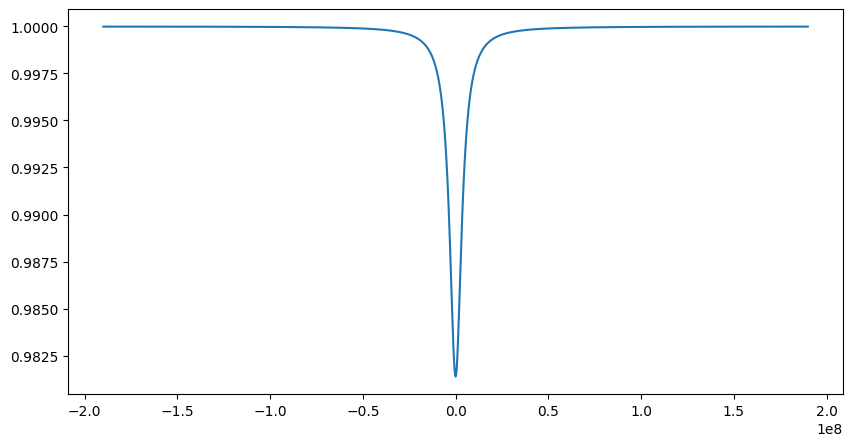

In [24]:
FSR = 2*np.pi*c/L

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
omegas = np.linspace(-0.5*FSR, 0.5*FSR, 10000)
r = r_cav(r1, r2, r3, r4, omegas)
ax.plot(omegas/(2*np.pi), np.abs(r)**2)   

Bandwidth (MHz):  7.772831133500361


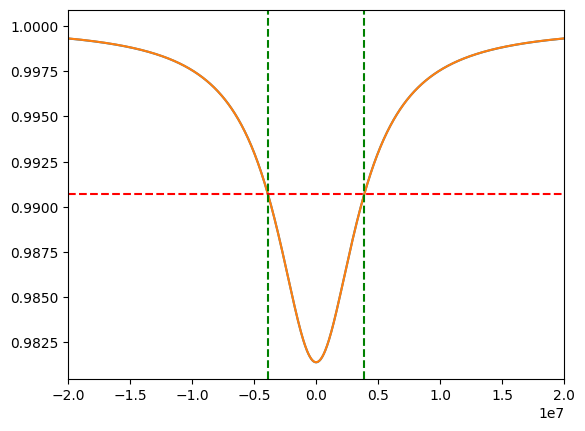

In [34]:
from scipy.optimize import curve_fit

def model(x,x_0,sigma,A):
    return 1-A/(1+(2*(x-x_0)/sigma)**2)

x = omegas/(2*np.pi)
popt, pcov = curve_fit(model, x, np.abs(r)**2, p0=[0, 0.1e8, 0.0175])
print("Bandwidth (MHz): ", popt[1]/1e6)

x_0, sigma, A = popt
plt.plot(omegas/(2*np.pi), np.abs(r)**2)
plt.plot(omegas/(2*np.pi), model(omegas/(2*np.pi), *popt), label='fit')
plt.xlim(-0.2e8, 0.2e8)
plt.axhline(1-(1-np.min(np.abs(r)**2))/2, color='red', linestyle='--', label='half maximum')
plt.axvline(sigma/2, color='green', linestyle='--', label='half width at half maximum')
plt.axvline(-sigma/2, color='green', linestyle='--')
